# Steam Games: EDA for Rachel
**Main question:** What makes a Steam game commercially successful?

Six visualizations: **2 easy, 3 medium, 1 moderately challenging**.
This notebook reads Keerat's exported `steam_clean.csv`. It does not redo or overwrite the cleaning.
Chinmayi's slides use `success_50k`: **owners_low >= 50,000**. 
The main analysis includes all cleaned games to match the group's ML population, including zero-price games.




## 1. Load the exported data and check the group definition
Leave `PAID_ONLY = False` for the main charts so they match the slides and ML population.
For an optional robustness check, set it to True and rerun from here. Paid-only results save to a separate folder.
If a file is not found, set `DATA_PATH` to its full path on your computer.


In [1]:
from pathlib import Path
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
from IPython.display import display

DATA_PATH = Path('clean_output/steam_clean.csv')
PAID_ONLY = False
MIN_GROUP_N = 100  # minimum games for the medium-chart comparisons
MIN_HEATMAP_N = 30  # suppress sparse genre/price cells; not a significance test

if not DATA_PATH.exists() and Path('steam_clean.csv').exists():
    DATA_PATH = Path('steam_clean.csv')
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f'No steam_clean.csv found. Current folder: {Path.cwd()}. '
        'Ask Keerat for the exported CSV, or run the cleaning notebook through Step 9. '
        'Then update DATA_PATH if needed.'
    )

required = ['AppID', 'Name', 'Price', 'owners_low', 'owners_high', 'success_50k',
            'release_date', 'publisher', 'genres']
data = pd.read_csv(DATA_PATH, low_memory=False)
missing = sorted(set(required) - set(data.columns))
if missing:
    raise ValueError(f'Missing columns: {missing}. Use steam_clean.csv, not raw games.csv or the model file.')
if data.empty or data['AppID'].isna().any() or data['AppID'].duplicated().any():
    raise ValueError('Expected one row per game with a unique, nonmissing AppID.')
for col in ['Price', 'owners_low', 'owners_high', 'success_50k']:
    data[col] = pd.to_numeric(data[col], errors='coerce')
    if data[col].isna().any() or not np.isfinite(data[col]).all():
        raise ValueError(f'{col} has missing or nonfinite values; check the export with Keerat.')
data['release_date'] = pd.to_datetime(data['release_date'], errors='coerce')
if data['release_date'].isna().any():
    raise ValueError('Some release dates could not be parsed.')
if (data['Price'] < 0).any() or (data['owners_low'] < 0).any():
    raise ValueError('Negative price/ownership values need review.')
if (data['owners_high'] <= 0).any() or (data['owners_high'] < data['owners_low']).any():
    raise ValueError('Unexpected ownership ranges in the cleaned export.')
expected_target = data['owners_low'].ge(50_000).astype(int)
if not data['success_50k'].eq(expected_target).all():
    raise ValueError('success_50k differs from owners_low >= 50,000. Confirm the team definition.')
data['success_50k'] = data['success_50k'].astype(int)

# Use explicit columns, not the cleaning notebook's publisher_n_games:
# that field counts ALL retained games, including future releases relative to each title.
data['publisher'] = data['publisher'].fillna('Unknown').astype(str).str.strip()
data.loc[data['publisher'].eq(''), 'publisher'] = 'Unknown'
data['genre_list'] = data['genres'].fillna('').astype(str).apply(
    lambda value: list(dict.fromkeys(g.strip() for g in value.split(',') if g.strip()))
)

# Strictly earlier dates only. Multiple games released on the same day get the same prior count.
known = data.loc[data['publisher'].str.casefold().ne('unknown')]
pub_dates = (known.groupby(['publisher', 'release_date']).size()
             .rename('games_on_date').reset_index()
             .sort_values(['publisher', 'release_date']))
pub_dates['publisher_prior_games'] = (
    pub_dates.groupby('publisher')['games_on_date'].cumsum() - pub_dates['games_on_date']
)
data = data.merge(pub_dates[['publisher', 'release_date', 'publisher_prior_games']],
                  on=['publisher', 'release_date'], how='left', validate='many_to_one')

df = data.loc[data['Price'].gt(0)].copy() if PAID_ONLY else data.copy()
if df.empty:
    raise ValueError('No games remain in the selected scope.')
scope = 'Paid games' if PAID_ONLY else 'All cleaned games'
OUT = Path('eda_output_paid' if PAID_ONLY else 'eda_output_all')
FIG = OUT / 'figures'
TABLE = OUT / 'tables'
FIG.mkdir(parents=True, exist_ok=True)
TABLE.mkdir(parents=True, exist_ok=True)
baseline = df['success_50k'].mean() * 100
print(f'Loaded {len(data):,} games. Analysis scope: {scope}, n={len(df):,}.')
print(f'50K-owner threshold: {df.success_50k.sum():,} games ({baseline:.2f}%).')
print(f'Compared with saved cleaning output: rows {len(data):,} vs 95,787; '
      f'threshold count {data.success_50k.sum():,} vs 14,018.')
if len(data) != 95_787 or data.success_50k.sum() != 14_018:
    print('CHECK WITH TEAM: this export differs from the saved notebook/slides. This is not automatically an error.')
display(df[required].head())


Loaded 95,787 games. Analysis scope: All cleaned games, n=95,787.
50K-owner threshold: 14,018 games (14.63%).
Compared with saved cleaning output: rows 95,787 vs 95,787; threshold count 14,018 vs 14,018.


,AppID,Name,Price,owners_low,owners_high,success_50k,release_date,publisher,genres
0,496350,Supipara - Chapter 1 Spring Has Come!,5.24,0,20000,0,2016-07-29,MangaGamer,Adventure
1,1034400,Mystery Solitaire The Black Raven,4.99,0,20000,0,2019-05-06,8floor,Casual
2,3292190,버튜버 파라노이아 - Vtuber Paranoia,8.99,0,20000,0,2024-10-31,유진게임즈,"Casual, Indie, Simulation"
3,3631080,Maze Quest VR,4.99,0,20000,0,2025-04-24,Reality Expanded LLC,"Action, Early Access"
4,1654170,Agony VR,13.99,0,20000,0,2023-04-05,Ignibit,"Action, Adventure"


## 2. A brief EDA summary and plotting helpers
This is a summary table, not one of the six visualizations. Median and quartiles summarize the skewed price distribution.
The ownership bounds remain bounds; we do not turn them into exact sales or multiply a midpoint by current price to claim revenue.

The reusable `rate_table` calculates the percentage meeting the threshold and Wilson 95% intervals.
These intervals describe binomial count uncertainty only. They do not include errors in SteamSpy ownership estimates,
dataset selection, or dependence among games. Overlap/non-overlap is not a formal hypothesis test.


In [2]:
BLUE, ORANGE, GREY = '#2a78d6', '#eb6834', '#898781'
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 300,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.titleweight': 'bold', 'axes.titlesize': 15})

summary = pd.Series({
    'Games analyzed': len(df),
    'Games meeting 50K-owner threshold': int(df.success_50k.sum()),
    'Threshold rate (%)': round(baseline, 2),
    'Zero-price games': int(df.Price.eq(0).sum()),
    'Median listed price (USD)': df.Price.median(),
    'Price 25th percentile (USD)': df.Price.quantile(.25),
    'Price 75th percentile (USD)': df.Price.quantile(.75),
    'Earliest release': str(df.release_date.min().date()),
    'Latest retained release': str(df.release_date.max().date())
}, name='Value')
display(summary.to_frame())
summary.to_csv(TABLE / '00_data_summary.csv')
comparison = (data.assign(price_scope=np.where(data.Price.eq(0), 'Zero listed price', 'Paid'))
              .groupby('price_scope').success_50k.agg(games='size', hits='sum', rate='mean'))
comparison['rate'] *= 100
display(comparison.rename(columns={'rate': 'threshold_rate_pct'}))

def rate_table(frame, group):
    t = frame.groupby(group, observed=True)['success_50k'].agg(games='size', hits='sum')
    p = t.hits / t.games
    z = 1.96
    denominator = 1 + z*z / t.games
    center = (p + z*z / (2*t.games)) / denominator
    half = z*np.sqrt(p*(1-p)/t.games + z*z/(4*t.games*t.games)) / denominator
    t['rate_pct'] = p * 100
    t['lower_pct'] = (center-half) * 100
    t['upper_pct'] = (center+half) * 100
    return t

def export_chart(fig, stem, note):
    fig.text(.01, .015, f'{scope}. {note}', fontsize=9, color='#555555', va='bottom')
    fig.tight_layout(rect=(0, .10, 1, 1))
    fig.savefig(FIG / f'{stem}.png', bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print('Saved:', FIG / f'{stem}.png')

def plot_rates(table, title, stem, note):
    # One reusable horizontal dot plot with sample sizes and count-based intervals.
    t = table.copy()
    if t.empty:
        raise ValueError('No groups meet MIN_GROUP_N. Review group counts before lowering the threshold.')
    fig, ax = plt.subplots(figsize=(10, max(4.8, .52*len(t)+1.8)))
    y = np.arange(len(t))
    errors = np.vstack([t.rate_pct-t.lower_pct, t.upper_pct-t.rate_pct])
    ax.errorbar(t.rate_pct, y, xerr=errors, fmt='o', markersize=7,
                color=BLUE, ecolor=BLUE, capsize=3)
    ax.set_yticks(y, [f'{label}  (n={int(n):,})' for label,n in zip(t.index,t.games)])
    ax.invert_yaxis()
    ax.axvline(baseline, ls='--', color=ORANGE, label=f'All games in this scope: {baseline:.1f}%')
    ax.set_xlim(0, min(100, max(float(t.upper_pct.max()), baseline)*1.22+2))
    ax.xaxis.set_major_formatter(PercentFormatter(100))
    ax.set_xlabel('Games meeting the 50K-owner threshold (%)')
    ax.set_title(title, loc='left', pad=18)
    ax.grid(axis='y', visible=False)
    ax.legend(loc='best', fontsize=9, frameon=False)
    t.to_csv(TABLE / f'{stem}.csv')
    display(t.round(2))
    export_chart(fig, stem, note + '\nDots = observed rates; lines = Wilson 95% intervals (ownership uncertainty excluded).')


,Value
Games analyzed,95787
Games meeting 50K-owner threshold,14018
Threshold rate (%),14.63
Zero-price games,9592
Median listed price (USD),2.99
Price 25th percentile (USD),0.99
Price 75th percentile (USD),5.99
Earliest release,1997-06-30
Latest retained release,2025-09-01


,games,hits,threshold_rate_pct
price_scope,,,
Paid,86195,11715,13.591276
Zero listed price,9592,2303,24.009591


## Chart 1 — Easy: How common is ownership-based success?
**Question:** What proportion of cleaned Steam games meet the 50K-owner threshold?

**Chart:** Two-bar class balance chart, with counts and percentages.



,games,percent
Below threshold,81769,85.37
Meets threshold,14018,14.63


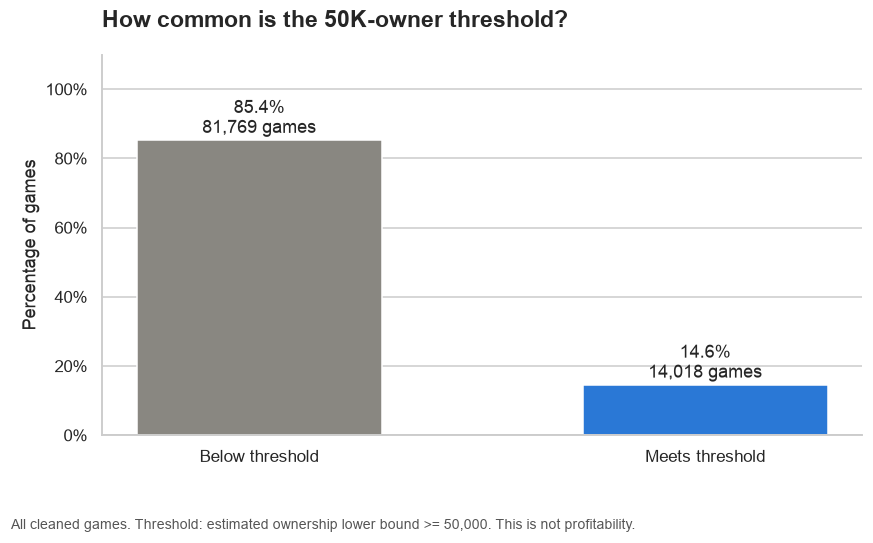

Saved: eda_output_all/figures/01_success_balance.png


In [3]:
counts = df.success_50k.value_counts().reindex([0, 1], fill_value=0)
percents = counts / len(df) * 100
t1 = pd.DataFrame({'games': counts, 'percent': percents})
t1.index = ['Below threshold', 'Meets threshold']
t1.to_csv(TABLE / '01_success_balance.csv')
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(t1.index, t1.percent, color=[GREY, BLUE], width=.55)
for bar, n, p in zip(bars, counts, percents):
    ax.text(bar.get_x()+bar.get_width()/2, p+2, f'{p:.1f}%\n{n:,} games', ha='center')
ax.set_ylim(0, 110)
ax.set_yticks([0,20,40,60,80,100])
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.set_ylabel('Percentage of games')
ax.set_title('How common is the 50K-owner threshold?', loc='left', pad=18)
ax.grid(axis='x', visible=False)
display(t1.round(2))
export_chart(fig, '01_success_balance', 'Threshold: estimated ownership lower bound >= 50,000. This is not profitability.')


## Chart 2 — Easy: Does the threshold rate differ by release cohort?
**Question:** How does the share meeting the 50K-owner threshold differ across release periods?

**Chart:** Simple bar chart of threshold rates by release cohort. Counts appear over the bars.



,games,hits,rate_pct,lower_pct,upper_pct
release_cohort,,,,,
Before 2010,653,462,70.75,67.15,74.11
2010–2014,2755,1820,66.06,64.27,67.81
2015–2019,26636,5420,20.35,19.87,20.84
2020–2022,28172,3683,13.07,12.68,13.47
2023–2024,27047,2222,8.22,7.89,8.55
2025 onward,10524,411,3.91,3.55,4.29


,games,hits,rate
release_date,,,
2016,4028,1350,33.52
2017,5745,1141,19.86
2018,7318,1034,14.13
2019,7090,906,12.78
2020,8626,1277,14.80
2021,9521,1285,13.50
2022,10025,1121,11.18
2023,11586,1149,9.92
2024,15461,1073,6.94


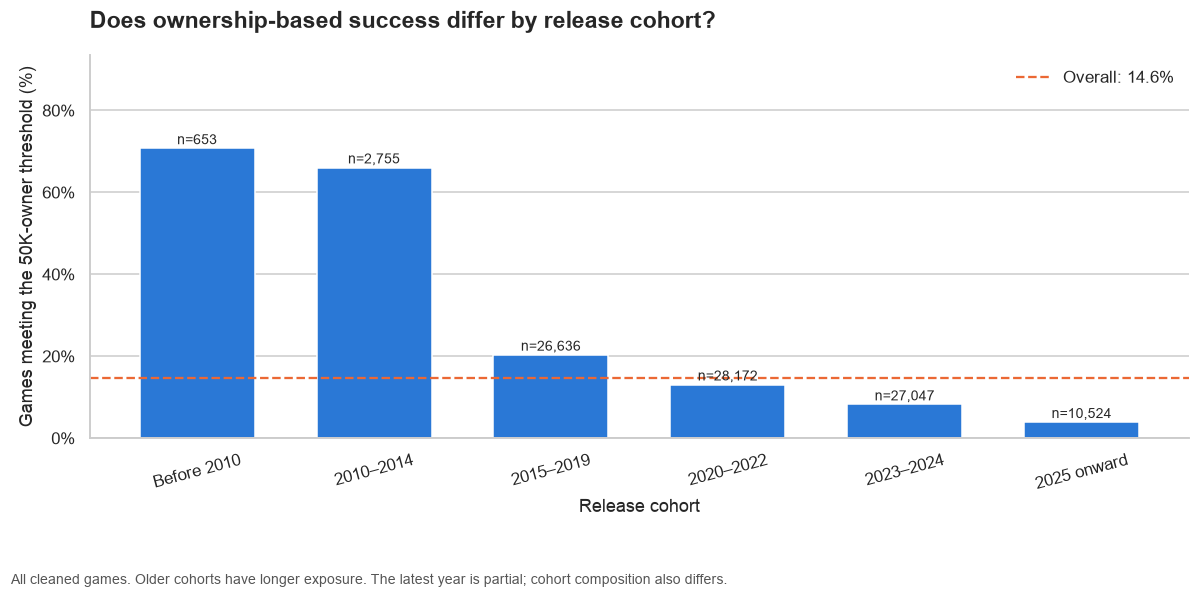

Saved: eda_output_all/figures/02_release_cohorts.png


In [4]:
cohort_labels = ['Before 2010', '2010–2014', '2015–2019', '2020–2022', '2023–2024', '2025 onward']
df['release_cohort'] = pd.cut(df.release_date.dt.year,
    bins=[-np.inf, 2009, 2014, 2019, 2022, 2024, np.inf], labels=cohort_labels)
t2 = rate_table(df, 'release_cohort')
t2.to_csv(TABLE / '02_release_cohorts.csv')
annual = df.groupby(df.release_date.dt.year)['success_50k'].agg(games='size', hits='sum', rate='mean')
annual['rate'] *= 100
annual.to_csv(TABLE / '02_annual_counts.csv')
fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.bar(t2.index.astype(str), t2.rate_pct, color=BLUE, width=.65)
for b, n in zip(bars, t2.games):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+1, f'n={n:,}', ha='center', fontsize=9)
ax.axhline(baseline, color=ORANGE, ls='--', label=f'Overall: {baseline:.1f}%')
ax.set_ylim(0, min(110, max(t2.rate_pct.max(), baseline)*1.25+5))
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.set_ylabel('Games meeting the 50K-owner threshold (%)')
ax.set_xlabel('Release cohort')
ax.set_title('Does ownership-based success differ by release cohort?', loc='left', pad=18)
ax.tick_params(axis='x', labelrotation=15)
ax.legend(frameon=False)
ax.grid(axis='x', visible=False)
display(t2.round(2))
display(annual.tail(10).round(2))
export_chart(fig, '02_release_cohorts', 'Older cohorts have longer exposure. The latest year is partial; cohort composition also differs.')


## Chart 3 — Medium: How does listed price relate to success?
**Question:** Which listed-price groups have higher rates of meeting the 50K-owner threshold?

**Chart:** Grouped rates with intervals, after creating price bins. This uses original `Price`, not capped price.
Zero listed price is shown separately. Prices above $100 are retained in their own group if the sample threshold is met.



,games,hits,rate_pct,lower_pct,upper_pct
price_group,,,,,
Zero listed price,9592,2303,24.01,23.17,24.87
$0–5 (excl. 0),59458,7359,12.38,12.11,12.64
$5–10,16823,2436,14.48,13.96,15.02
$10–20,8025,1512,18.84,18.00,19.71
$20–40,1415,356,25.16,22.97,27.49
$40–100,302,51,16.89,13.08,21.52
Above $100,172,1,0.58,0.10,3.22


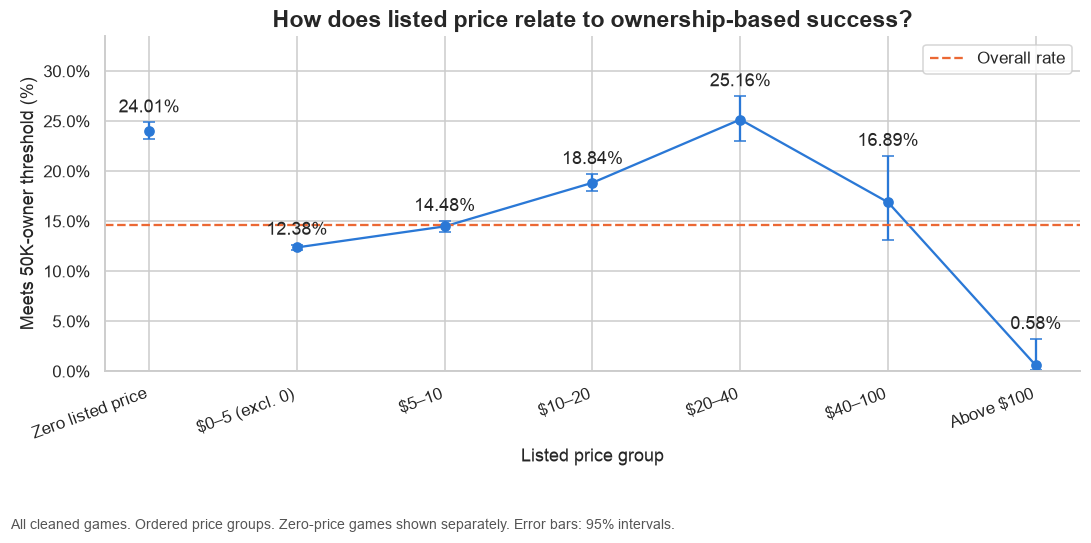

Saved: eda_output_all/figures/03_price_rates.png


In [10]:
price_labels = ["Zero listed price", "$0–5 (excl. 0)", "$5–10",
                "$10–20", "$20–40", "$40–100", "Above $100"]

df["price_group"] = pd.cut(
    df["Price"], [-np.inf, 0, 5, 10, 20, 40, 100, np.inf],
    labels=price_labels
)
t3_all = rate_table(df, "price_group")
t3 = t3_all.loc[t3_all.games >= MIN_GROUP_N]
display(t3.round(2))
t3_all.to_csv(TABLE / "03_price_all_groups.csv")
t3.to_csv(TABLE / "03_price_rates.csv")

x = np.arange(len(t3))
paid = t3.index != "Zero listed price"
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x[paid], t3.rate_pct[paid], "-", color=BLUE)
ax.errorbar(
    x, t3.rate_pct,
    yerr=np.maximum(0, [t3.rate_pct - t3.lower_pct,
                       t3.upper_pct - t3.rate_pct]),
    fmt="o", color=BLUE, capsize=4
)
for i, rate in enumerate(t3.rate_pct):
    ax.text(i, t3.upper_pct.iloc[i] + 1, f"{rate:.2f}%", ha="center")

ax.axhline(baseline, color=ORANGE, ls="--", label="Overall rate")
ax.set_xticks(x, t3.index, rotation=20, ha="right")
ax.set_ylim(0, t3.upper_pct.max() + 6)
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.set(xlabel="Listed price group", ylabel="Meets 50K-owner threshold (%)",
       title="How does listed price relate to ownership-based success?")
ax.legend()
export_chart(fig, "03_price_rates",
             "Ordered price groups. Zero-price games shown separately. Error bars: 95% intervals.")

## Chart 4 — Medium: Which genres have higher threshold rates?
**Question:** Among common game genres, which have higher shares meeting the 50K-owner threshold?

**Chart:** Rates with intervals for the ten most common eligible genres, ordered by observed rate.


,games,hits,rate_pct,lower_pct,upper_pct
genre,,,,,
Massively Multiplayer,1862,604,32.44,30.35,34.60
RPG,17712,3530,19.93,19.35,20.52
Strategy,18965,3494,18.42,17.88,18.98
Action,39747,6507,16.37,16.01,16.74
Adventure,38655,5951,15.40,15.04,15.76
Simulation,20159,3077,15.26,14.77,15.77
Racing,3457,485,14.03,12.91,15.23
Indie,68697,8935,13.01,12.76,13.26
Sports,4160,513,12.33,11.37,13.37


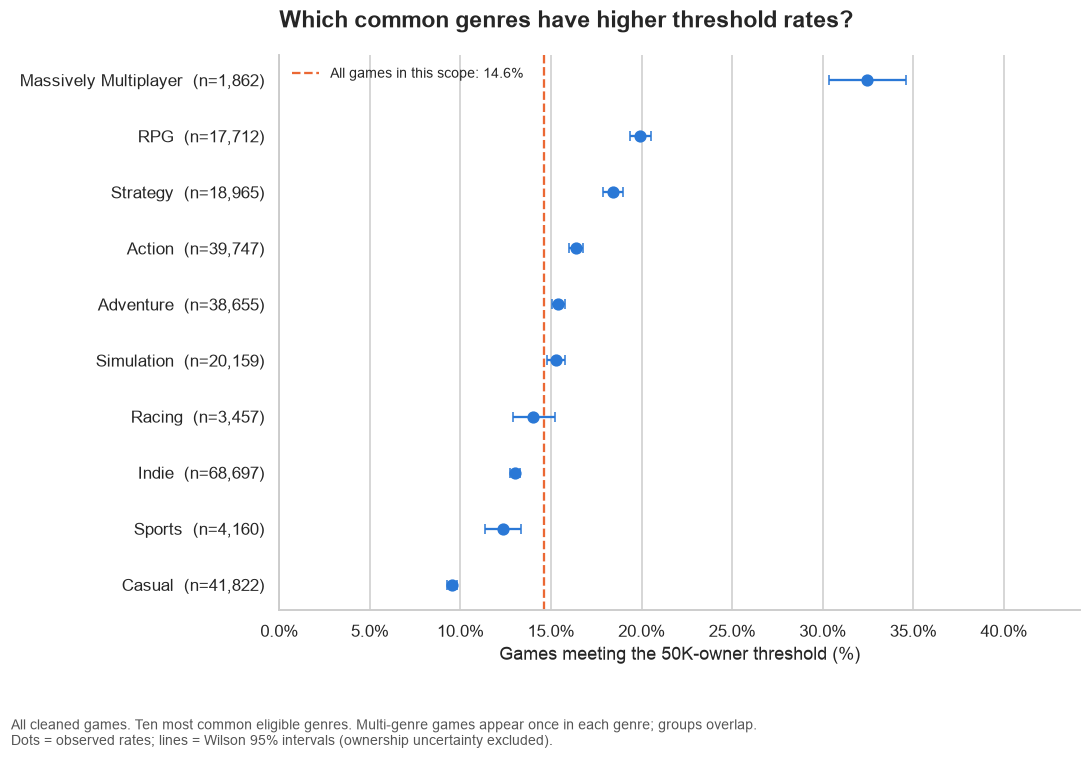

Saved: eda_output_all/figures/04_genre_rates.png


In [6]:
excluded_genres = {s.casefold() for s in [
    'Free To Play', 'Early Access', 'Utilities', 'Design & Illustration', 'Animation & Modeling',
    'Audio Production', 'Video Production', 'Photo Editing', 'Web Publishing', 'Education',
    'Software Training', 'Accounting', 'Game Development', 'Movie', 'Documentary',
    'Episodic', 'Short', 'Tutorial', '360 Video']}
genre_long = df.explode('genre_list').rename(columns={'genre_list': 'genre'})
genre_long = genre_long.loc[genre_long.genre.notna()].copy()
genre_long = genre_long.loc[~genre_long.genre.str.casefold().isin(excluded_genres)]
genre_long = genre_long.drop_duplicates(['AppID', 'genre'])
genre_counts = genre_long.groupby('genre').size().sort_values(ascending=False)
top_genres = genre_counts[genre_counts >= MIN_GROUP_N].head(10).index.tolist()
if not top_genres:
    raise ValueError('No eligible genres have enough games; inspect genres and group sizes.')
t4 = rate_table(genre_long.loc[genre_long.genre.isin(top_genres)], 'genre').sort_values('rate_pct', ascending=False)
plot_rates(t4, 'Which common genres have higher threshold rates?', '04_genre_rates',
           'Ten most common eligible genres. Multi-genre games appear once in each genre; groups overlap.')


## Chart 5 — Medium: Does prior publisher experience relate to success?
**Question:** Do games linked to publishers with more earlier releases have higher threshold rates?

**Chart:** Rates by number of prior games in the retained catalogue: 0, 1–4, 5–19, 20+.


,games,hits,rate_pct,lower_pct,upper_pct
experience_group,,,,,
0 prior games,51503,5747,11.16,10.89,11.43
1–4 prior games,22600,3559,15.75,15.28,16.23
5–19 prior games,10818,2417,22.34,21.57,23.14
20+ prior games,10339,2187,21.15,20.38,21.95


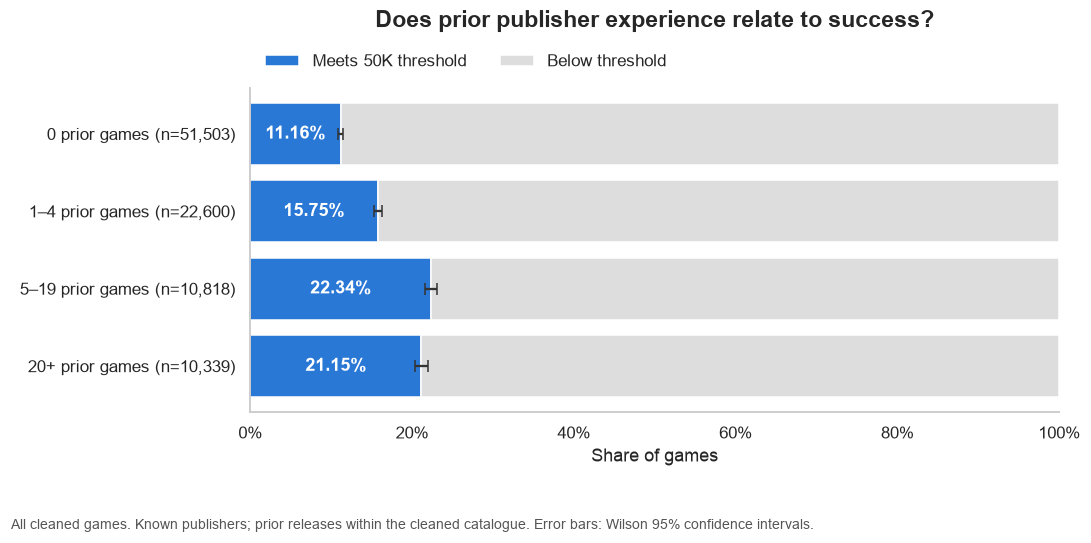

Saved: eda_output_all/figures/05_publisher_rates.png


In [11]:
publisher_df = df.loc[df.publisher_prior_games.notna()].copy()
publisher_df["experience_group"] = pd.cut(
    publisher_df.publisher_prior_games,
    bins=[-1, 0, 4, 19, np.inf],
    labels=["0 prior games", "1–4 prior games",
            "5–19 prior games", "20+ prior games"]
)
t5_all = rate_table(publisher_df, "experience_group")
t5 = t5_all.loc[t5_all.games >= MIN_GROUP_N]
display(t5.round(2))
t5_all.to_csv(TABLE / "05_publisher_all_groups.csv")
t5.to_csv(TABLE / "05_publisher_rates.csv")

y = np.arange(len(t5))
s = t5.rate_pct
fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(y, s, color=BLUE, label="Meets 50K threshold")
ax.barh(y, 100 - s, left=s, color="#dddddd", label="Below threshold")
ax.errorbar(
    s, y,
    xerr=np.maximum(0, [s - t5.lower_pct, t5.upper_pct - s]),
    fmt="none", ecolor="#333333", capsize=4
)
for i, rate in enumerate(s):
    ax.text(rate / 2, i, f"{rate:.2f}%",
            ha="center", va="center", color="white", fontweight="bold")

ax.set_yticks(y, [f"{g} (n={n:,})" for g, n in zip(t5.index, t5.games)])
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(PercentFormatter(100))
ax.set_xlabel("Share of games")
ax.set_title("Does prior publisher experience relate to success?", pad=40)
ax.grid(False)
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.01),
          ncol=2, frameon=False)

export_chart(fig, "05_publisher_rates",
             "Known publishers; prior releases within the cleaned catalogue. "
             "Error bars: Wilson 95% confidence intervals.")

## Chart 6 — Hard, but manageable: Does the price pattern differ by genre?
**Question:** How does the share meeting the 50K-owner threshold vary across genre–price combinations?

**Chart:** Heatmap of percentages for the eight most common eligible genres crossed with price groups.


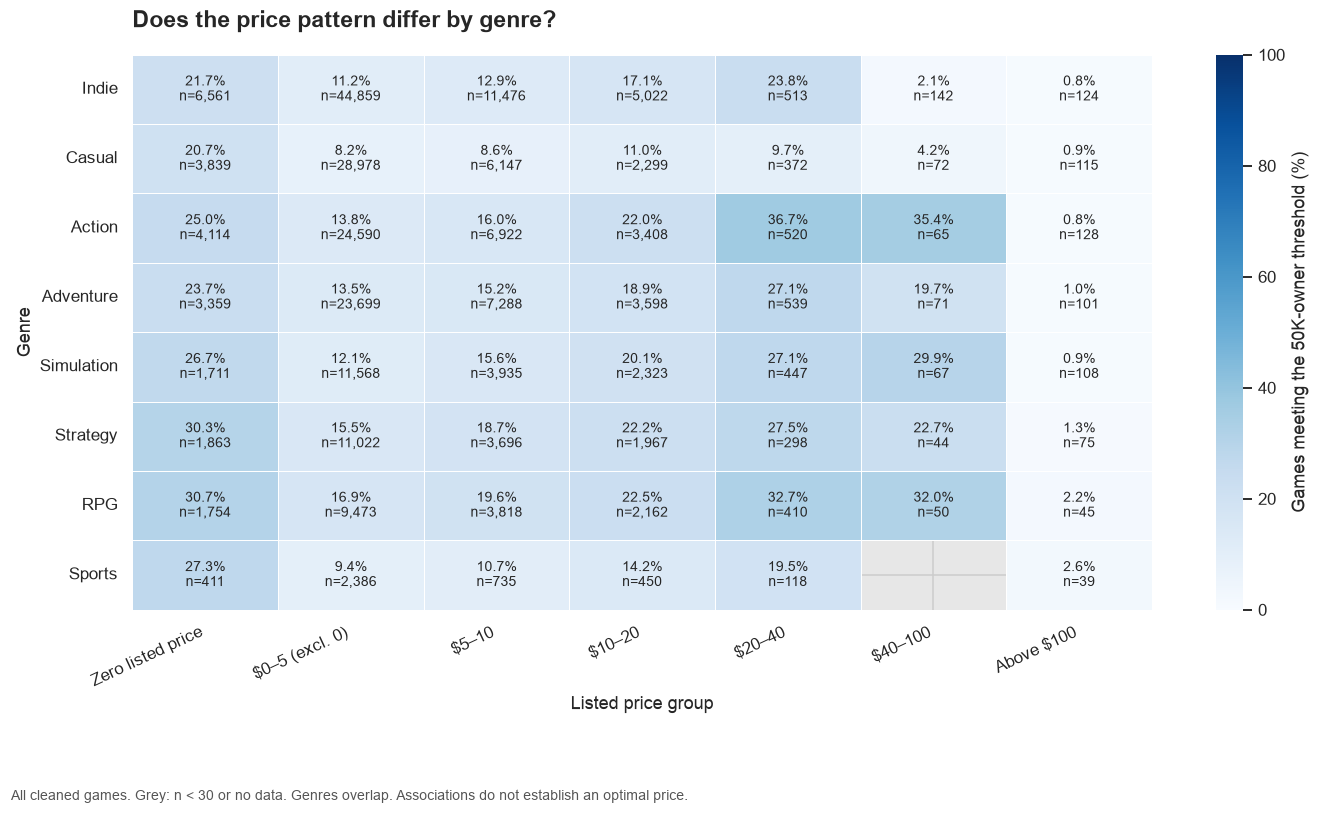

Saved: eda_output_all/figures/06_genre_price_heatmap.png


In [8]:
heat_genres = genre_counts[genre_counts >= MIN_GROUP_N].head(8).index.tolist()
heat_data = genre_long.loc[genre_long.genre.isin(heat_genres)]
combo = (heat_data.groupby(['genre', 'price_group'], observed=True)['success_50k']
         .agg(games='size', hits='sum').reset_index())
combo['rate_pct'] = combo.hits / combo.games * 100
combo.to_csv(TABLE / '06_genre_price_cells.csv', index=False)
present_prices = [p for p in price_labels if p in combo.price_group.astype(str).unique()]
rates = combo.pivot(index='genre', columns='price_group', values='rate_pct').reindex(index=heat_genres, columns=present_prices)
sizes = combo.pivot(index='genre', columns='price_group', values='games').reindex(index=heat_genres, columns=present_prices)
mask = sizes.isna() | sizes.lt(MIN_HEATMAP_N)
annotations = pd.DataFrame('', index=rates.index, columns=rates.columns)
for genre in rates.index:
    for price in rates.columns:
        if not mask.loc[genre, price]:
            annotations.loc[genre, price] = f'{rates.loc[genre, price]:.1f}%\nn={int(sizes.loc[genre, price]):,}'
if mask.to_numpy().all():
    raise ValueError('All cells have insufficient data. Inspect the count table before changing the threshold.')
fig, ax = plt.subplots(figsize=(13, 7.5))
ax.set_facecolor('#e7e7e7')
sns.heatmap(rates, mask=mask, annot=annotations, fmt='', cmap='Blues', vmin=0, vmax=100,
            linewidths=.6, linecolor='white', annot_kws={'fontsize':9},
            cbar_kws={'label': 'Games meeting the 50K-owner threshold (%)'}, ax=ax)
ax.set_xlabel('Listed price group')
ax.set_ylabel('Genre')
ax.set_title('Does the price pattern differ by genre?', loc='left', pad=18)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
export_chart(fig, '06_genre_price_heatmap',
             f'Grey: n < {MIN_HEATMAP_N} or no data. Genres overlap. Associations do not establish an optimal price.')


In [9]:
# Save provenance and the exact analysis choices beside the charts.
file_hash = hashlib.sha256()
with DATA_PATH.open('rb') as handle:
    for block in iter(lambda: handle.read(1024*1024), b''):
        file_hash.update(block)
notes = [
    f'Input file: {DATA_PATH.name}', f'SHA256: {file_hash.hexdigest()}',
    f'Scope: {scope}', f'Games analyzed: {len(df):,}',
    'Target: owners_low >= 50,000; proxy only, not observed revenue/profit',
    f'Group minimum n: {MIN_GROUP_N}; heatmap minimum n: {MIN_HEATMAP_N}',
    'Publisher experience: strictly earlier releases in full cleaned catalogue; first publisher only',
    'No models fitted; no causal conclusions; no chart conclusions predetermined'
]
(OUT / 'analysis_notes.txt').write_text('\n'.join(notes), encoding='utf-8')
print('Six charts saved:')
for path in sorted(FIG.glob('*.png')):
    print(path)
print('Supporting tables:', TABLE.resolve())


Six charts saved:
eda_output_all/figures/01_success_balance.png
eda_output_all/figures/02_release_cohorts.png
eda_output_all/figures/03_price_rates.png
eda_output_all/figures/04_genre_rates.png
eda_output_all/figures/05_publisher_rates.png
eda_output_all/figures/06_genre_price_heatmap.png
Supporting tables: /Users/rachel_huang/fa26/DATA 230/Steam project/eda_output_all/tables
